# ResNet18 Features + 7 Classical ML Classifiers — 4-Class Skin Cancer (ISIC)

This notebook does **feature extraction + classical ML**, not end-to-end deep learning:

1. Downloads the dataset **directly into Colab** via `kagglehub` (no `kaggle.json` file — you'll paste your Kaggle username + API key once when prompted).
2. Picks the same **4 classes** as your earlier runs.
3. Runs a **pretrained ResNet18** (ImageNet weights, no fine-tuning) over every image to get a 512-number feature vector per image — this is called using ResNet18 as a "feature extractor".
4. Trains **7 classical ML classifiers** on those feature vectors:
   - Logistic Regression
   - Decision Tree
   - Random Forest
   - K-Nearest Neighbors (KNN)
   - Linear SVM
   - RBF-SVM
   - XGBoost
5. Prints one final **comparison table** with Accuracy, Precision, Recall, F1-Score, AUC for all 7, plus a bar chart.

Set Colab's runtime to **GPU** first: `Runtime > Change runtime type > T4 GPU` (only needed to speed up the ResNet18 feature extraction step — the classifiers themselves run on CPU).

In [ ]:
!pip install -q kagglehub scikit-learn xgboost seaborn

## 1. Download dataset via kagglehub
First run will ask you to authenticate. Go to https://www.kaggle.com/settings -> **API** -> **Create New Token** — copy-paste the username and key it shows you. No file download needed.

In [ ]:
import kagglehub

path = kagglehub.dataset_download("nodoubttome/skin-cancer9-classesisic")
print("Dataset downloaded to:", path)

Using Colab cache for faster access to the 'skin-cancer9-classesisic' dataset.
Dataset downloaded to: /kaggle/input/skin-cancer9-classesisic


## 2. Find the class folders and select 4 classes

In [ ]:
import os, glob

candidate_dirs = [d for d in glob.glob(os.path.join(path, '**'), recursive=True) if os.path.isdir(d)]
class_dir, all_classes = None, []
for d in sorted(candidate_dirs, key=lambda x: x.count(os.sep)):
    subdirs = sorted([s for s in os.listdir(d) if os.path.isdir(os.path.join(d, s))])
    if len(subdirs) >= 4:
        class_dir, all_classes = d, subdirs
        break

print("Class folder:", class_dir)
print("All classes found:", all_classes)

# ---- EDIT THIS LIST if you want specific classes (use the SAME 4 as your other runs) ----
SELECTED_CLASSES = all_classes[:4]
print("\nSelected classes for training:", SELECTED_CLASSES)

Class folder: /kaggle/input/skin-cancer9-classesisic/Skin cancer ISIC The International Skin Imaging Collaboration/Test
All classes found: ['actinic keratosis', 'basal cell carcinoma', 'dermatofibroma', 'melanoma', 'nevus', 'pigmented benign keratosis', 'seborrheic keratosis', 'squamous cell carcinoma', 'vascular lesion']

Selected classes for training: ['actinic keratosis', 'basal cell carcinoma', 'dermatofibroma', 'melanoma']


In [ ]:
import shutil

filtered_dir = "/content/filtered_dataset"
if os.path.exists(filtered_dir):
    shutil.rmtree(filtered_dir)
os.makedirs(filtered_dir)

for cls in SELECTED_CLASSES:
    os.symlink(os.path.join(class_dir, cls), os.path.join(filtered_dir, cls))

print("Filtered 4-class dataset ready at:", filtered_dir)

Filtered 4-class dataset ready at: /content/filtered_dataset


## 3. Build dataset & split into train/test

In [ ]:
import torch
from torchvision import transforms, datasets
from torch.utils.data import DataLoader, random_split

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

full_dataset = datasets.ImageFolder(filtered_dir, transform=transform)
class_names = full_dataset.classes
print("Class-to-index mapping:", full_dataset.class_to_idx)

train_size = int(0.8 * len(full_dataset))
test_size = len(full_dataset) - train_size

train_ds, test_ds = random_split(
    full_dataset, [train_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

BATCH_SIZE = 32
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"Train: {len(train_ds)}  Test: {len(test_ds)}")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Class-to-index mapping: {'actinic keratosis': 0, 'basal cell carcinoma': 1, 'dermatofibroma': 2, 'melanoma': 3}
Train: 51  Test: 13
Using device: cuda


## 4. Extract 512-dim features from every image using pretrained ResNet18
We remove ResNet18's final classification layer, so its output becomes a 512-number feature vector per image instead of class scores. No training happens here — the weights are frozen ImageNet weights.

In [ ]:
import torch.nn as nn
from torchvision import models
import numpy as np

resnet = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
resnet.fc = nn.Identity()  # strip the final classifier -> outputs raw 512-dim features
resnet = resnet.to(device)
resnet.eval()

def extract_features(loader):
    feats, labels_list = [], []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(device)
            out = resnet(imgs).cpu().numpy()
            feats.append(out)
            labels_list.append(labels.numpy())
    return np.concatenate(feats), np.concatenate(labels_list)

print("Extracting train features...")
X_train, y_train = extract_features(train_loader)
print("Extracting test features...")
X_test, y_test = extract_features(test_loader)

print("X_train shape:", X_train.shape, " X_test shape:", X_test.shape)

Extracting train features...
Extracting test features...
X_train shape: (51, 512)  X_test shape: (13, 512)


In [ ]:
from sklearn.preprocessing import StandardScaler

# Scale features - important for KNN and SVM especially
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 5. Define the 7 classifiers

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

classifiers = {
    "Logistic Regression": LogisticRegression(max_iter=2000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Linear SVM": SVC(kernel="linear", probability=True, random_state=42),
    "RBF-SVM": SVC(kernel="rbf", probability=True, random_state=42),
    "XGBoost": XGBClassifier(eval_metric="mlogloss", random_state=42),
}

## 6. Train + evaluate each classifier

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.preprocessing import label_binarize

results = []
y_test_bin = label_binarize(y_test, classes=list(range(len(class_names))))

for name, clf in classifiers.items():
    print(f"Training {name}...")
    clf.fit(X_train_scaled, y_train)
    preds = clf.predict(X_test_scaled)
    probs = clf.predict_proba(X_test_scaled)

    acc = accuracy_score(y_test, preds) * 100
    prec = precision_score(y_test, preds, average='macro', zero_division=0) * 100
    rec = recall_score(y_test, preds, average='macro', zero_division=0) * 100
    f1 = f1_score(y_test, preds, average='macro', zero_division=0) * 100

    try:
        auc = roc_auc_score(y_test_bin, probs, average='macro', multi_class='ovr') * 100
    except Exception as e:
        auc = float('nan')
        print(f"AUC could not be computed for {name}:", e)

    print(f"  Accuracy={acc:.2f}%  Precision={prec:.2f}%  Recall={rec:.2f}%  F1={f1:.2f}%  AUC={auc:.2f}%\n")

    results.append({"Classifier": name, "Accuracy (%)": acc, "Precision (%)": prec,
                     "Recall (%)": rec, "F1-Score (%)": f1, "AUC (%)": auc})

Training Logistic Regression...
  Accuracy=84.62%  Precision=85.42%  Recall=85.42%  F1=85.42%  AUC=90.83%

Training Decision Tree...
  Accuracy=53.85%  Precision=45.00%  Recall=54.17%  F1=48.89%  AUC=69.39%

Training Random Forest...
  Accuracy=76.92%  Precision=80.42%  Recall=77.08%  F1=73.47%  AUC=91.36%

Training KNN...
  Accuracy=69.23%  Precision=72.92%  Recall=72.92%  F1=72.32%  AUC=87.29%

Training Linear SVM...
  Accuracy=84.62%  Precision=85.42%  Recall=85.42%  F1=85.42%  AUC=91.67%

Training RBF-SVM...
  Accuracy=69.23%  Precision=70.00%  Recall=72.92%  F1=69.84%  AUC=84.86%

Training XGBoost...
  Accuracy=61.54%  Precision=50.00%  Recall=54.17%  F1=50.95%  AUC=85.40%



## 7. Final comparison table

In [ ]:
import pandas as pd

results_df = pd.DataFrame(results).set_index("Classifier").round(2)
results_df

,Accuracy (%),Precision (%),Recall (%),F1-Score (%),AUC (%)
Classifier,,,,,
Logistic Regression,84.62,85.42,85.42,85.42,90.83
Decision Tree,53.85,45.00,54.17,48.89,69.39
Random Forest,76.92,80.42,77.08,73.47,91.36
KNN,69.23,72.92,72.92,72.32,87.29
Linear SVM,84.62,85.42,85.42,85.42,91.67
RBF-SVM,69.23,70.00,72.92,69.84,84.86
XGBoost,61.54,50.00,54.17,50.95,85.40


## 8. (Optional) Bar chart comparing all 7 classifiers

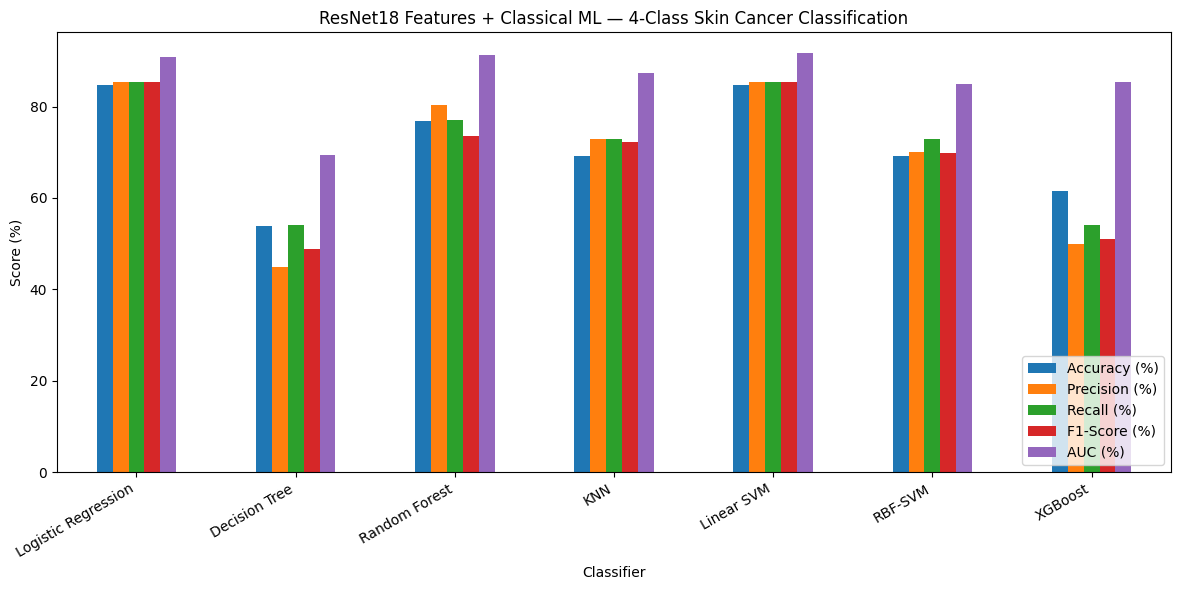

In [ ]:
import matplotlib.pyplot as plt

results_df.plot(kind="bar", figsize=(12, 6))
plt.title("ResNet18 Features + Classical ML — 4-Class Skin Cancer Classification")
plt.ylabel("Score (%)")
plt.xticks(rotation=30, ha="right")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()